## __Data Science: Capstone Part 2: Lightning Talk 2__

### Overview

On the **One** topic you have selected you would need to:
1. Refine your problem statement. for more info [ML-Framing-a-Data-Science-Problem]() **<--- will cover on Tuesday**
2. Create / Compile a data dictionary
3. Clean the data and Perform in-depth EDA (Insights + EDA for Modeling)
4. Outline proposed preprocessing/feature engineering and models

### Presentation Requirements (5 Minutes)
* Refined Problem Statement  (including Success Metrics)
* Potential Audience
* Goals & Objectives
    * Type of Models (e.g: Regression/Classification)
    * Number of models
    * Evaluation Metrics
* About the data (Data Dictionary and EDA for Modeling) - Keep this short 
* Progress report (Challenges & Next Steps)



___Note: EDA for Image based Topics___
* Classes (Target)
* Settings (Transformation)
* Data Limitations


# [Real Estate Price Prediction ]
Data Source : [https://www.kaggle.com/datasets/harlfoxem/housesalesprediction]

# Problem Statement
House prices fluctuate significantly, and buyers and sellers may face substantially different property prices depending on factors such as living area, number of bedrooms, bathrooms, location, house condition, grade, waterfront view, and year built. These price variations make it difficult for customers to determine whether a property is reasonably priced and make informed purchasing or selling decisions.

The objective of this project is to analyze the factors influencing house prices and develop a machine learning model to predict house prices based on property characteristics. By providing accurate price estimates, the model aims to support buyers and sellers in making more informed real estate decisions and better understand the factors that contribute to property value.

## Objectives
List the key questions guiding your analysis and modeling:
- What features influence the target variable?
- Can feature engineering improve model performance?
- How do different model versions compare?

# Data Inspection

## Data Dictionary
| Column         | Type    | Description |
| -------------- | ------- | ------------ |
| id             | int     | Unique house identifier |
| date           | object  | Date the house was sold |
| price          | float   | **Target.** Sale price |
| bedrooms       | int     | Number of bedrooms |
| bathrooms      | float   | Number of bathrooms |
| sqft_living    | int     | Living space square footage |
| sqft_lot       | int     | Lot square footage |
| floors         | float   | Number of floors |
| waterfront     | int     | 1 if property has waterfront view |
| view           | int     | Quality of view (0-4 scale) |
| condition      | int     | Overall condition rating (1-5) |
| grade          | int     | Construction/design quality grade |
| sqft_above     | int     | Square footage above ground |
| sqft_basement  | int     | Square footage of basement |
| yr_built       | int     | Year house was built |
| yr_renovated   | int     | Year renovated (0 if never) |
| zipcode        | int     | Zip code |
| lat / long     | float   | Latitude / longitude |
| sqft_living15  | int     | Living space of nearest 15 neighbors (avg) |
| sqft_lot15     | int     | Lot size of nearest 15 neighbors (avg) |

In [61]:
# organize your imports in this cell
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import f_regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
accuracy_score,
roc_auc_score,
confusion_matrix,
classification_report,
recall_score,
precision_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

import warnings
warnings.filterwarnings('ignore')

## Data Overview
Load and inspect the dataset
- Source and format
- .head(), .info(), .describe(),…

In [4]:
df = pd.read_csv('./Data/kc_house_data.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [62]:
df.shape

(21613, 24)

In [63]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15', 'is_studio', 'house_age',
       'is_renovated'],
      dtype='object')

# Data Cleaning
Handle missing values, outliers, and inconsistencies

In [5]:
# handle missing values
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [6]:
df['date'] = pd.to_datetime(df['date'])
df['bathrooms'] = df['bathrooms'].astype(int)
df['floors'] = df['floors'].astype(int)
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.0,3,1,1180,5650,1,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,2014-12-09,538000.0,3,2,2570,7242,2,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2015-02-25,180000.0,2,1,770,10000,1,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,2014-12-09,604000.0,4,3,1960,5000,1,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2015-02-18,510000.0,3,2,1680,8080,1,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


# Exploratory Data Analysis (EDA)
Answer objectives using visual and statistical insights
- Trends, relationships, anomalies
- Outlier and missing values treatment
- Univariate, bivariate, or multivariate analysis
    - Histograms, box plots, bar charts
    - Correlation matrix for continuous columns (required if applicable)


In [7]:
df.describe()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,2014-10-29 04:38:01.959931648,5.400881e+05,3.370842,1.749734,2079.899736,1.510697e+04,1.446213,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
min,1.000102e+06,2014-05-02 00:00:00,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,2014-07-22 00:00:00,3.219500e+05,3.000000,1.000000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,2014-10-16 00:00:00,4.500000e+05,3.000000,2.000000,1910.000000,7.618000e+03,1.000000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,2015-02-17 00:00:00,6.450000e+05,4.000000,2.000000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,2015-05-27 00:00:00,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.000000,1.000000,4.000000,...,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000
std,2.876566e+09,NaN,3.671272e+05,0.930062,0.734873,918.440897,4.142051e+04,0.551894,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631


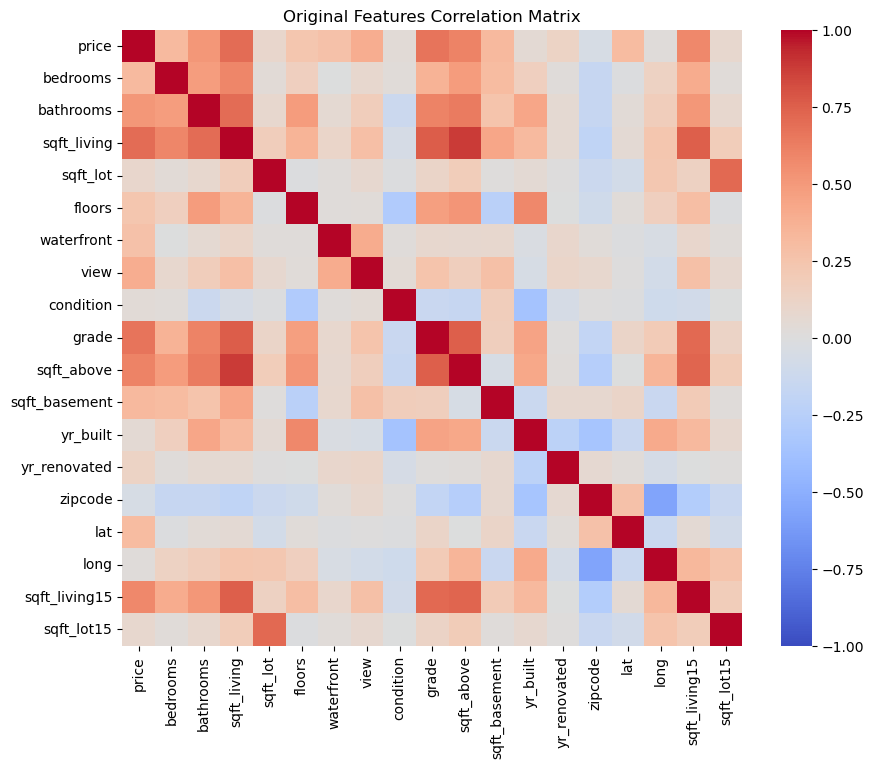

In [59]:

original_cols = [
    'price',
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'floors',
    'waterfront',
    'view',
    'condition',
    'grade',
    'sqft_above',
    'sqft_basement',
    'yr_built',
    'yr_renovated',
    'zipcode',
    'lat',
    'long',
    'sqft_living15',
    'sqft_lot15',
]

corr_original = df[original_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_original, cmap='coolwarm', annot=False, vmin=-1, vmax=1)
plt.title('Original Features Correlation Matrix')

plt.savefig('original_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

<Axes: xlabel='price', ylabel='Count'>

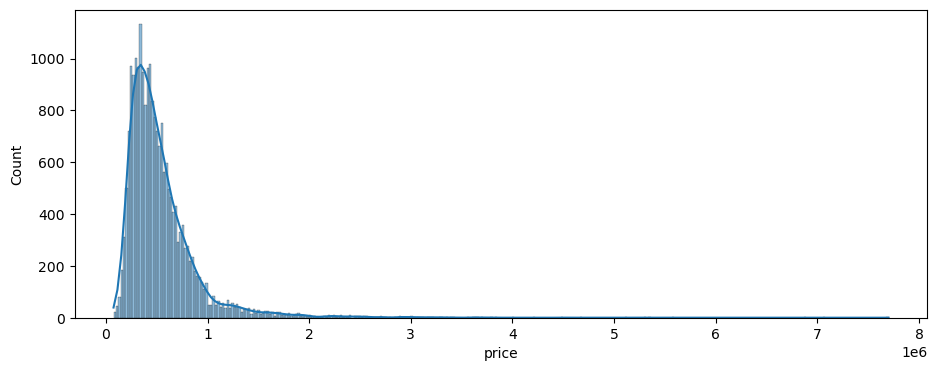

In [44]:
# Target distribution: price
figs = plt.subplots( figsize=(11, 4))
sns.histplot(df['price'], kde=True)


In [45]:

def get_all_outliers(data):
    outlier_list = []
    numeric_df = data.select_dtypes(include=['number'])
    
    for col in numeric_df.columns:
        Q1 = numeric_df[col].quantile(0.25)
        Q3 = numeric_df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        count = ((numeric_df[col] < (Q1 - 1.5 * IQR)) | (numeric_df[col] > (Q3 + 1.5 * IQR))).sum()
        percentage = round((count / len(numeric_df)) * 100, 2)
        
        outlier_list.append({'Column': col, 'Outliers Count': count, 'Percentage (%)': percentage})
        
    return pd.DataFrame(outlier_list)

get_all_outliers(df)

,Column,Outliers Count,Percentage (%)
0,id,0,0.00
1,price,1146,5.30
2,bedrooms,545,2.52
3,bathrooms,402,1.86
4,sqft_living,572,2.65
5,sqft_lot,2425,11.22
6,floors,0,0.00
7,waterfront,163,0.75
8,view,2124,9.83
9,condition,30,0.14


In [52]:
Q1 = df['lat'].quantile(0.25)
Q3 = df['lat'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df[(df['lat'] < lower_bound) | (df['lat'] > upper_bound)]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,is_studio,house_age,is_renovated
3295,9413400165,2014-06-24,380000.0,3,2,1860,15559,2,0,0,...,1963,0,98022,47.1559,-121.646,1110,11586,0,51,0
15599,619079016,2014-06-02,687000.0,4,3,4400,186846,2,0,0,...,1993,0,98022,47.1593,-121.957,2280,186846,0,21,0


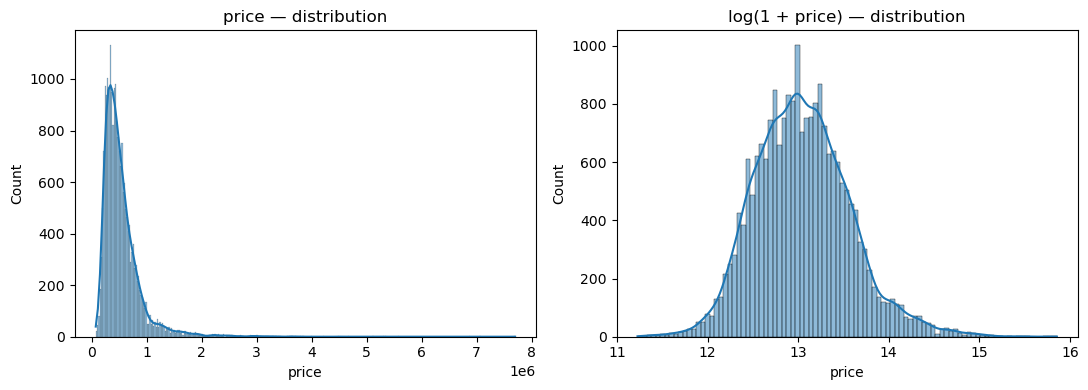

count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64


In [10]:
# Target distribution: price
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['price'], kde=True, ax=axes[0])
axes[0].set_title('price — distribution')

sns.histplot(np.log1p(df['price']), kde=True, ax=axes[1])
axes[1].set_title('log(1 + price) — distribution')
plt.tight_layout()
plt.show()

print(df['price'].describe())

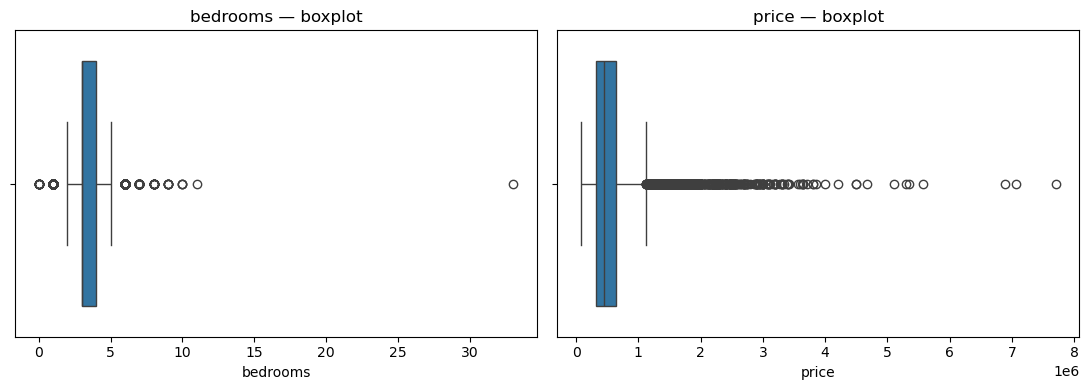

Homes with 10+ bedrooms:
       bedrooms  bathrooms  sqft_living      price
8757         11          3         3000   520000.0
13314        10          5         4590  1148000.0
15161        10          2         3610   650000.0
15870        33          1         1620   640000.0
19254        10          3         2920   660000.0

price: IQR upper bound = 1129575.00, rows above = 1146


In [14]:
# Outlier check: bedrooms (known data quality issue) and price
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x=df['bedrooms'], ax=axes[0])
axes[0].set_title('bedrooms — boxplot')

sns.boxplot(x=df['price'], ax=axes[1])
axes[1].set_title('price — boxplot')
plt.tight_layout()
plt.show()

print("Homes with 10+ bedrooms:")
print(df[df['bedrooms'] >= 10][['bedrooms', 'bathrooms', 'sqft_living', 'price']])

q1, q3 = df['price'].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f"\nprice: IQR upper bound = {upper:.2f}, rows above = {(df['price'] > upper).sum()}")

In [15]:
df.loc[df['bedrooms'] == 33, 'bedrooms'] = 3

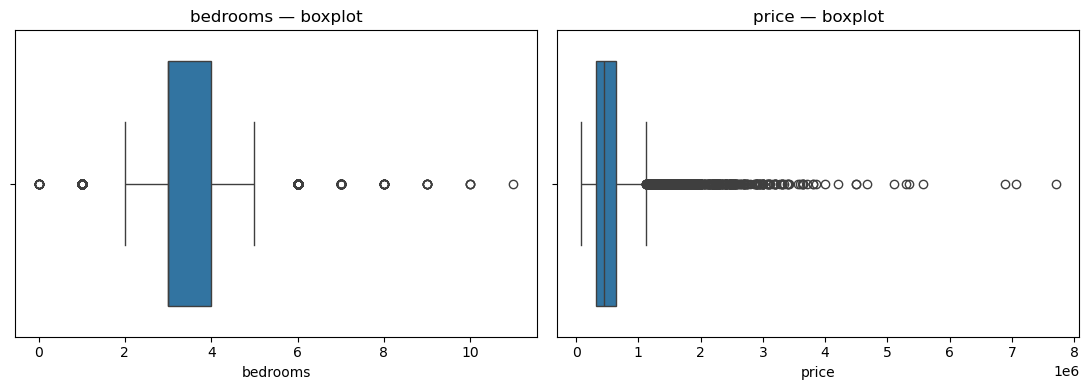

Homes with 10+ bedrooms:
       bedrooms  bathrooms  sqft_living      price
8757         11          3         3000   520000.0
13314        10          5         4590  1148000.0
15161        10          2         3610   650000.0
19254        10          3         2920   660000.0

price: IQR upper bound = 1129575.00, rows above = 1146


In [16]:
# Outlier check: bedrooms (known data quality issue) and price
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x=df['bedrooms'], ax=axes[0])
axes[0].set_title('bedrooms — boxplot')

sns.boxplot(x=df['price'], ax=axes[1])
axes[1].set_title('price — boxplot')
plt.tight_layout()
plt.show()

print("Homes with 10+ bedrooms:")
print(df[df['bedrooms'] >= 10][['bedrooms', 'bathrooms', 'sqft_living', 'price']])

q1, q3 = df['price'].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f"\nprice: IQR upper bound = {upper:.2f}, rows above = {(df['price'] > upper).sum()}")

In [17]:
df['is_studio'] = ((df['bedrooms'].isin([0, 1])) & (df['sqft_living'] < 600)).astype(int)

In [18]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,is_studio
0,7129300520,2014-10-13,221900.0,3,1,1180,5650,1,0,0,...,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,0
1,6414100192,2014-12-09,538000.0,3,2,2570,7242,2,0,0,...,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,0
2,5631500400,2015-02-25,180000.0,2,1,770,10000,1,0,0,...,770,0,1933,0,98028,47.7379,-122.233,2720,8062,0
3,2487200875,2014-12-09,604000.0,4,3,1960,5000,1,0,0,...,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,0
4,1954400510,2015-02-18,510000.0,3,2,1680,8080,1,0,0,...,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,0


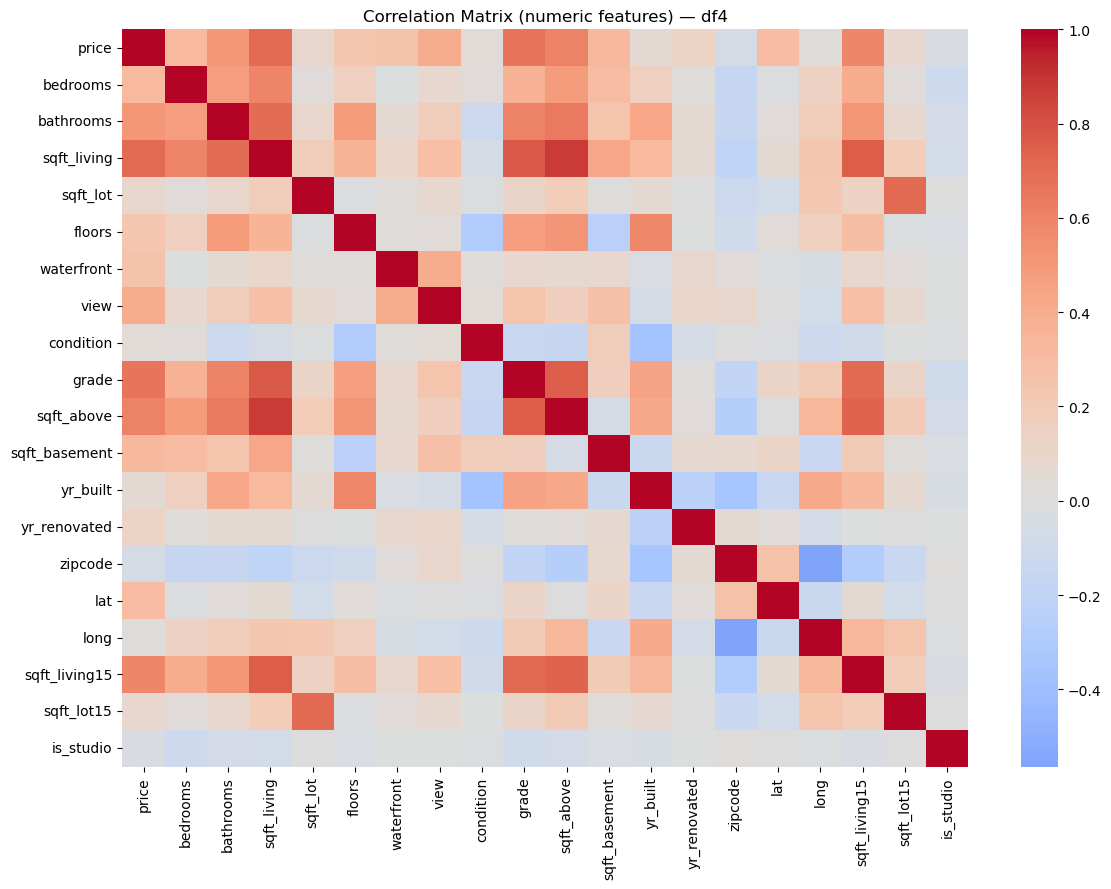

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.510072
view             0.397293
sqft_basement    0.323816
bedrooms         0.315438
lat              0.307003
Name: price, dtype: float64


In [19]:
num_cols4 = df.select_dtypes(include=np.number).columns.drop(['id']).tolist()
corr4 = df[num_cols4].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr4, cmap='coolwarm', center=0)
plt.title('Correlation Matrix (numeric features) — df4')
plt.tight_layout()
plt.show()

print(corr4['price'].sort_values(ascending=False).head(10))

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21613 non-null  int64         
 1   date           21613 non-null  datetime64[ns]
 2   price          21613 non-null  float64       
 3   bedrooms       21613 non-null  int64         
 4   bathrooms      21613 non-null  int32         
 5   sqft_living    21613 non-null  int64         
 6   sqft_lot       21613 non-null  int64         
 7   floors         21613 non-null  int32         
 8   waterfront     21613 non-null  int64         
 9   view           21613 non-null  int64         
 10  condition      21613 non-null  int64         
 11  grade          21613 non-null  int64         
 12  sqft_above     21613 non-null  int64         
 13  sqft_basement  21613 non-null  int64         
 14  yr_built       21613 non-null  int64         
 15  yr_renovated   2161

In [21]:
print("\n--- Top Numerical Correlations with Price ---")
num_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['id'], errors='ignore')
corr = num_df.corr()
top_corrs = corr['price'].sort_values(ascending=False)
print(top_corrs)


--- Top Numerical Correlations with Price ---
price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
view             0.397293
sqft_basement    0.323816
bedrooms         0.315438
lat              0.307003
waterfront       0.266369
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
zipcode         -0.053203
Name: price, dtype: float64


In [23]:
print(df['is_studio'].value_counts())

print(df.groupby('is_studio')['price'].mean())

is_studio
0    21577
1       36
Name: count, dtype: int64
is_studio
0    540590.392918
1    239058.333333
Name: price, dtype: float64


In [28]:
# Feature Engineering

# Calculate house age at the time of sale
df['house_age'] = df['date'].dt.year - df['yr_built']

# Create a renovation indicator
df['is_renovated'] = (df['yr_renovated'] > 0).astype(int)

# Check the new features
df[['yr_built', 'date', 'house_age', 'yr_renovated', 'is_renovated']].head()

,yr_built,date,house_age,yr_renovated,is_renovated
0,1955,2014-10-13,59,0,0
1,1951,2014-12-09,63,1991,1
2,1933,2015-02-25,82,0,0
3,1965,2014-12-09,49,0,0
4,1987,2015-02-18,28,0,0


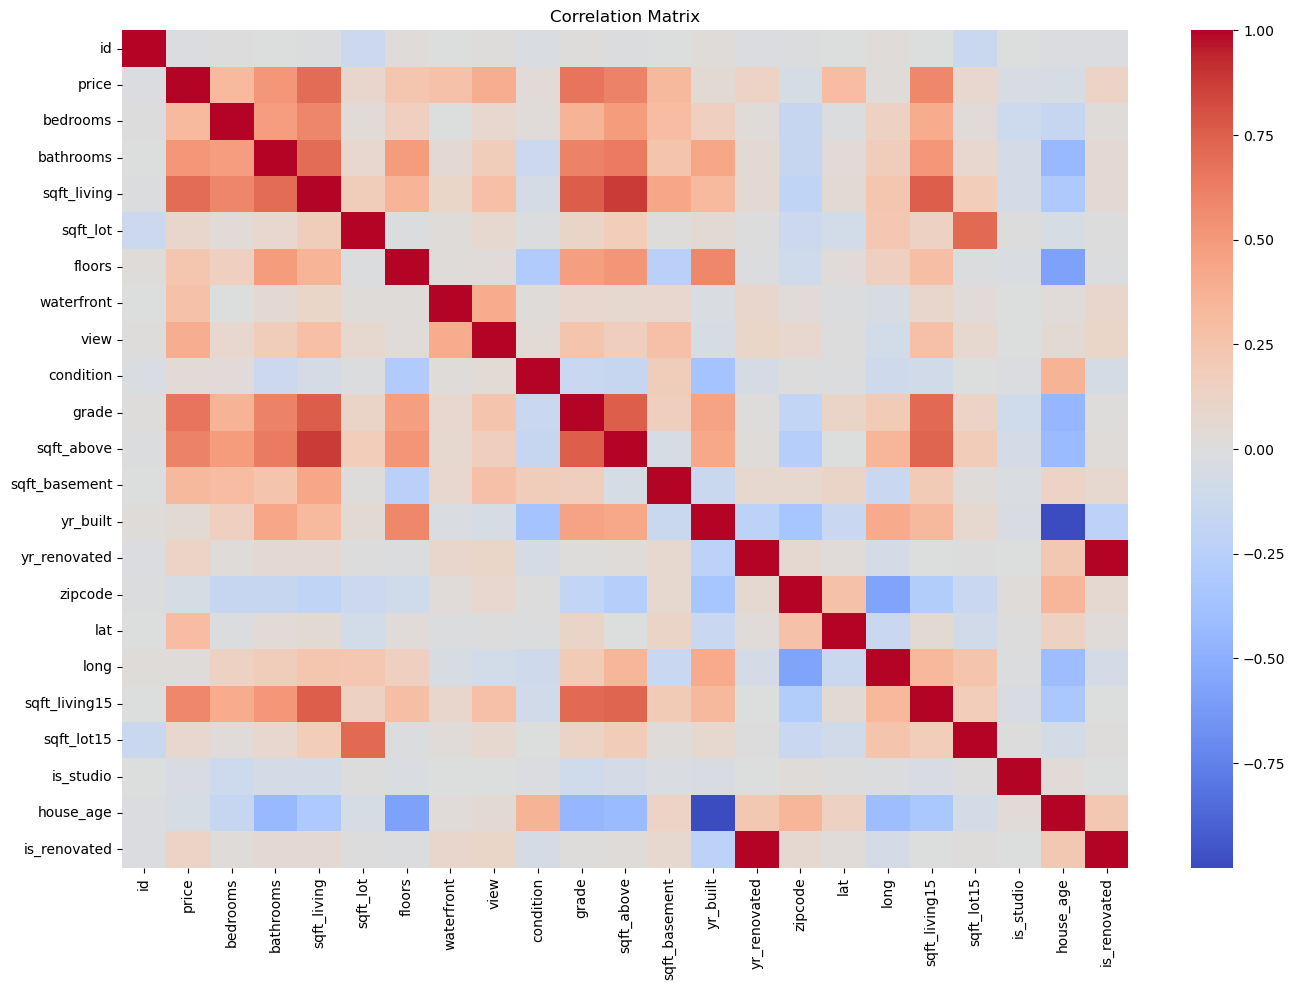

In [29]:
# Correlation Matrix

numeric_cols = df.select_dtypes(include=np.number)

corr = numeric_cols.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### EDA Insight

The correlation matrix helps identify which numerical features have the strongest relationships with house price. Features related to living space, such as sqft_living and sqft_above, are expected to have stronger positive relationships with price.

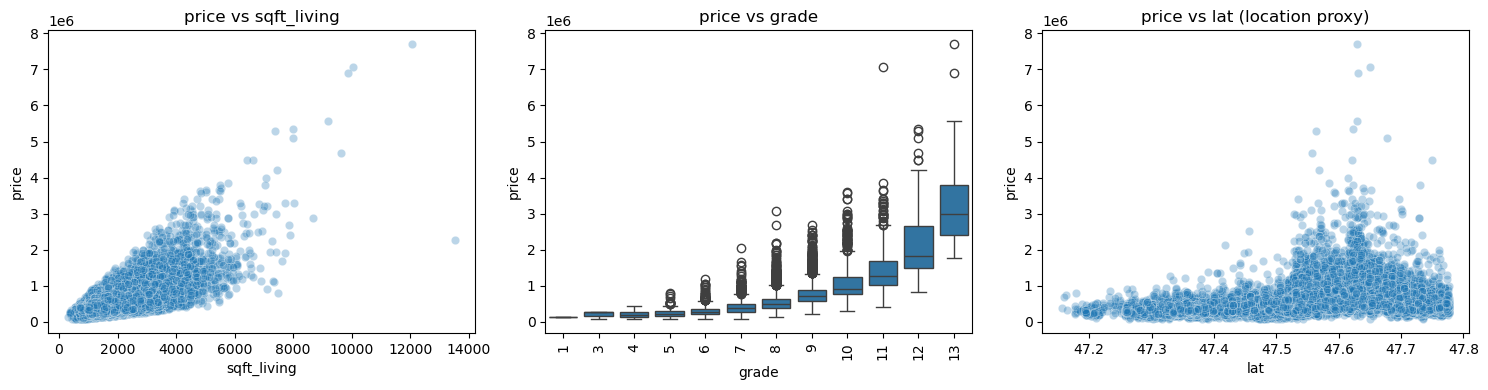

In [24]:
# Bivariate EDA: price vs. top correlated / intuitive drivers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(x=df['sqft_living'], y=df['price'], alpha=0.3, ax=axes[0])
axes[0].set_title('price vs sqft_living')

sns.boxplot(x=df['grade'], y=df['price'], ax=axes[1])
axes[1].set_title('price vs grade')
axes[1].tick_params(axis='x', rotation=90)

sns.scatterplot(x=df['lat'], y=df['price'], alpha=0.3, ax=axes[2])
axes[2].set_title('price vs lat (location proxy)')

plt.tight_layout()
plt.show()

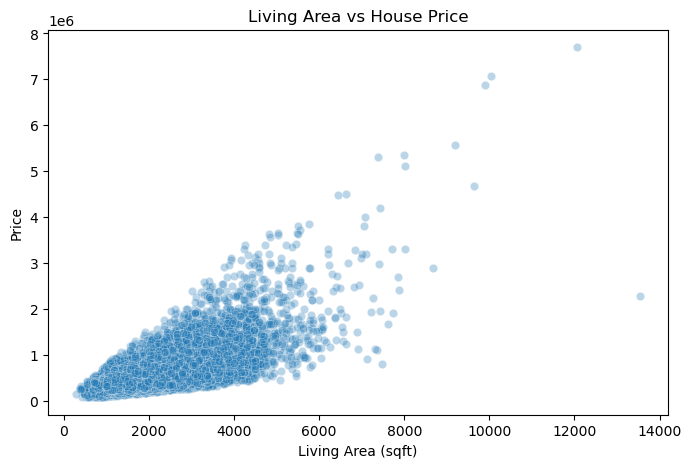

In [30]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='sqft_living',
    y='price',
    alpha=0.3
)

plt.title('Living Area vs House Price')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price')
plt.show()

### Insight

There is a clear positive relationship between living area and house price. In general, larger homes tend to have higher prices.

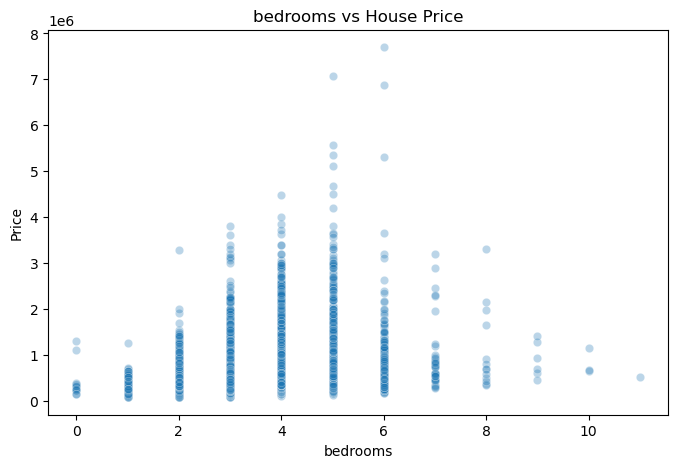

In [33]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='bedrooms',
    y='price',
    alpha=0.3
)

plt.title('bedrooms vs House Price')
plt.xlabel('bedrooms')
plt.ylabel('Price')
plt.show() 

### Insight

House prices generally vary across different numbers of bedrooms. However, the relationship is not completely linear, suggesting that other features also influence house prices.

In [34]:
# Define features and target

X = df.drop(columns=['price'])
y = df['price']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (21613, 23)
y shape: (21613,)


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (17290, 23)
Testing set: (4323, 23)


In [56]:
numerical_cols = df.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Features:", numerical_cols)
print("Categorical Features:", categorical_cols)

Numerical Features: ['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'is_studio', 'house_age', 'is_renovated']
Categorical Features: []


In [57]:
num_cols = []
cat_cols = []

for col in df.columns:
    if df[col].nunique() < 10 or df[col].dtype == 'object':
        cat_cols.append(col)
    else:
        num_cols.append(col)

print("Categorical Features:", cat_cols)
print("Numerical Features:", num_cols)

Categorical Features: ['bathrooms', 'floors', 'waterfront', 'view', 'condition', 'is_studio', 'is_renovated']
Numerical Features: ['id', 'date', 'price', 'bedrooms', 'sqft_living', 'sqft_lot', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'house_age']


In [58]:
cat_cols = ['zipcode', 'grade', 'condition', 'view', 'waterfront', 'is_studio', 'is_renovated']

clean_df = df.dropna(subset=cat_cols + ['price'])

f_values, p_values = f_regression(clean_df[cat_cols], clean_df['price'])

results = pd.DataFrame({
    'Feature': cat_cols,
    'F-statistic': np.round(f_values, 2),
    'Significance': [f"p < 0.001" if p < 0.001 else f"p = {p:.3f}" for p in p_values]
}).sort_values(by='F-statistic', ascending=False).reset_index(drop=True)

results.index = results.index + 1
results.index.name = 'Rank'

results

,Feature,F-statistic,Significance
Rank,,,
1,grade,17360.64,p < 0.001
2,view,4050.46,p < 0.001
3,waterfront,1650.46,p < 0.001
4,is_renovated,349.15,p < 0.001
5,zipcode,61.34,p < 0.001
6,condition,28.61,p < 0.001
7,is_studio,24.27,p < 0.001


## Evaluation Metrics

The regression models will be evaluated using:

- **MAE (Mean Absolute Error):** Measures the average absolute prediction error.
- **RMSE (Root Mean Squared Error):** Gives more weight to larger prediction errors.
- **R² Score:** Measures how well the model explains the variation in house prices.

Lower MAE and RMSE indicate better performance, while a higher R² indicates a better model.

In [38]:
linear_model = LinearRegression()

In [39]:

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [40]:

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

# Data Preprocessing & Feature Engineering
Transforming, encoding, standardization and preparing features
- **You only need to outline your approach here. No need to execute**

### Data Preprocessing & Feature Engineering Approach

#### 1. Outlier Handling & Data Corrections
* **Fix Entry Errors:** Correct known data entry anomalies (e.g., updating `bedrooms = 33` to `3` to align logically with its $1,620\text{ sq ft}$ area and single bathroom).
* **Impute Zero Bedrooms:** Impute properties with `0` bedrooms to `1` bedroom to maintain mathematical consistency in distance and regression models.

#### 2. Feature Engineering
* **Studio Apartment Flag:** Engineer a binary feature `is_studio` ($1$ if `bedrooms == 0` or `bedrooms == 1` with `sqft_living < 600`, else $0$) to isolate the distinct valuation dynamics of studio units.
* **Temporal Features:** Derive age-related variables such as property age at sale (`house_age = year_sold - yr_built`) and time since last renovation (`years_since_renovated`).

#### 3. Categorical & Ordinal Encoding
* **Ordinal Variables:** Retain numerical ordinal features (`grade`, `condition`, `view`, `waterfront`) as integers to preserve their natural ranking hierarchy.
* **Categorical Variables:** Apply **One-Hot Encoding** to non-ordinal categorical variables like `zipcode` to prevent artificial linear relationships.

#### 4. Feature Transformation & Scaling
* **Log Transformation:** Apply $\log(1 + x)$ to heavily right-skewed variables (e.g., `price`, `sqft_living`, `sqft_lot`) to normalize distributions and reduce variance distortion.
* **Standardization:** Scale continuous numerical features using **StandardScaler** to ensure distance- and regularization-sensitive algorithms (e.g., Ridge, Lasso, KNN) perform consistently.

# Modelling Approach
What are the models you are planning to build for your capstone.
- **You only need to outline your approach here. No need to execute**

#### 1. Baseline Model
* **Linear Regression:** Build a simple Multiple Linear Regression model to serve as the benchmark for evaluation metrics ($R^2$, $MAE$, $RMSE$).

#### 2. Regularized Linear Models
* **Ridge Regression ($L_2$ Regularization):** Apply Ridge to handle potential multicollinearity and reduce model variance.
* **Lasso Regression ($L_1$ Regularization):** Utilize Lasso for embedded feature selection by shrinking coefficients of non-informative features to zero.

#### 3. Advanced Non-Linear & Ensemble Models
* **Random Forest Regressor:** Train a decision tree ensemble to capture complex non-linear relationships and feature interactions without strict distributional assumptions.
* **XGBoost / LightGBM Regressor:** Implement gradient boosting algorithms to optimize predictive precision and handle complex non-linear patterns efficiently.

#### 4. Model Evaluation & Validation Approach
* **Data Splitting:** Partition the dataset into **Train** ($80\%$) and **Test** ($20\%$) sets using a fixed `random_state` to ensure reproducibility.
* **Cross-Validation:** Perform 5-Fold Cross-Validation on the training set to prevent overfitting and assess model stability.
* **Evaluation Metrics:** Evaluate all models using Root Mean Squared Error ($RMSE$), Mean Absolute Error ($MAE$), and $R^2$ Score.
* **Hyperparameter Tuning:** Tune optimal parameters for tree-based models using `GridSearchCV` or `RandomizedSearchCV`.

## Challenges

- The dataset contained a data quality issue in the bedrooms variable.
- House prices have a highly skewed distribution.
- Some features may have strong relationships with each other.
- Real estate prices can be affected by location and other factors that may not be fully captured by the dataset.

## Next Steps

- Train and compare multiple regression models.
- Tune the best-performing model.
- Evaluate model performance using MAE, RMSE, and R².
- Analyze feature importance to identify the main factors affecting house prices.
- Use the final model to predict house prices for new properties.